In [5]:
import pandas as pd

In [6]:
final_df = pd.read_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/letters/final_letter_data.csv")

In [7]:
final_df

,zendesk_id,attachment_id,attachment_url,s3_object_key,text_with_page_markers,text
0,16949451,16949451-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949451-1.pdf,<page_1>\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nK...,\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nKilger & ...
1,16949470,16949470-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949470-1.pdf,<page_1>\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEG...,\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\nD...
2,16949469,16949469-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949469-1.pdf,<page_1>\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SE...,\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\n...
3,16949477,16949477-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949477-1.pdf,<page_1>\nhamburger arbeit\nÖffentliche Schuld...,\nhamburger arbeit\nÖffentliche Schuldner- und...
4,16949480,16949480-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949480-1.pdf,<page_1>\nverbraucherzentrale\nSchleswig-Holst...,\nverbraucherzentrale\nSchleswig-Holstin\nSchu...
...,...,...,...,...,...,...
1050,16972231,16972231-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16972231-1.pdf,"<page_1>\nAndrea Reinecke\nBrettin, 01.10.2025...","\nAndrea Reinecke\nBrettin, 01.10.2025\nHeinri..."
1051,16918425,16918425-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16918425-1.pdf,<page_1>\nMelda Portakal\nHeiligkreuzgasse 34\...,\nMelda Portakal\nHeiligkreuzgasse 34\nGericht...
1052,16898832,16898832-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898832-1.pdf,<page_1>\nObergerichtsvollzieherin D. Donner\n...,\nObergerichtsvollzieherin D. Donner\nDienstko...
1053,16898843,16898843-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898843-1.pdf,<page_1>\nGerichtsvollzieherin\nSpessartstraße...,\nGerichtsvollzieherin\nSpessartstraße 46\nNic...


## Run `pfub_erlass` & `ladung` aftercourt classification models

Applies the exact same steps used in `intent_recognition` (`AftercourtService` /
`AfterCourtClassificationModel`) to the `text` column of the sample dataset:

1. Preprocess text (`normalize whitespace → drop short lines → strip HTML → lowercase`).
2. Replace entities with tags (`<DATE>`, `<GESCHAEFTSNUMMER>`, `<CUR>`, …) → `text_w_tags`.
3. Vectorize with the shared TF-IDF vectorizer (custom spaCy lemma tokenizer).
4. Run each model's `predict_proba` and apply its probability threshold.

Models/vectorizer are loaded from `notebooks/letters/models` (downloaded from
`s3://pair-email-classification/models/aftercourt_classification2`).

In [9]:
import os
import sys

import dill

# Repo root + intent_recognition must be importable so the pickled TF-IDF
# vectorizer can resolve its custom tokenizer (ClassificationSpacyLemmaTokenizer).
PROJECT_ROOT = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation"
INTENT_RECOG_DIR = os.path.join(PROJECT_ROOT, "intent_recognition")
if INTENT_RECOG_DIR not in sys.path:
    sys.path.insert(0, INTENT_RECOG_DIR)

# Importing the module registers the tokenizer class for unpickling.
import src.services.models.aftercourt_tokenizer  # noqa: F401
from src.services.attachment_processing.base_input_processor import (
    AfterCourtAttachmentPreprocessor,
)

MODELS_DIR = os.path.join(PROJECT_ROOT, "notebooks", "letters", "models")

In [28]:
from types import SimpleNamespace

# Preprocessing config — identical to the intent_recognition after_court model configs.
PREPROCESSING_CONFIG = SimpleNamespace(
    clean_text_type="preprocessed",
    normalize_whitespace=True,
    remove_short_lines=True,
    short_line_threshold=3,
    remove_html_tags=True,
    lowercase=True,
)

PREPROCESSING_CONFIG_PAGE_MARKERS = SimpleNamespace(
    clean_text_type="preprocessed",
    normalize_whitespace=True,
    remove_short_lines=True,
    short_line_threshold=3,
    remove_html_tags=False,
    lowercase=True,
)

# Shared TF-IDF vectorizer file + per-model classifier files and probability
# thresholds (from intent_recognition AfterCourtClassificationModel.prob_thresholds).
VECTORIZER_FILE = "05-12-2026_tf_idf_vectorizer_v1.dill"
MODEL_SPECS = {
    "pfub_erlass": {
        "model_file": "12-01-2026_binary_pfub_rf_classifier_v1.dill",
        "prob_threshold": 0.6,
    },
    "ladung_va": {
        "model_file": "18-02-2026_binary_ladung_rf_classifier_v1.dill",
        "prob_threshold": 0.6,
    },
}

In [30]:
# Load the shared TF-IDF vectorizer.
with open(os.path.join(MODELS_DIR, VECTORIZER_FILE), "rb") as f:
    tfidf_vectorizer = dill.load(f)

# Load the classification models.
models = {}
for ac_type, spec in MODEL_SPECS.items():
    with open(os.path.join(MODELS_DIR, spec["model_file"]), "rb") as f:
        models[ac_type] = dill.load(f)

# Preprocessor — same class and steps used by the service.
preprocessor = AfterCourtAttachmentPreprocessor(
    name="aftercourt_classification",
    preprocessing_config=PREPROCESSING_CONFIG,
)

preprocessor_page_markers = AfterCourtAttachmentPreprocessor(
    name="aftercourt_classification",
    preprocessing_config=PREPROCESSING_CONFIG_PAGE_MARKERS,
)
print("Loaded vectorizer and models:", list(models))

Loaded vectorizer and models: ['pfub_erlass', 'ladung_va']


In [31]:
# Build text_w_tags from the `text` column using the exact preprocessing steps.

def clean_text(text) -> str:
    text = "" if pd.isna(text) else str(text)
    preprocessed = preprocessor._process(text)
    return preprocessed
def to_text_w_tags(text) -> str:
    text = "" if pd.isna(text) else str(text)
    cleaned = clean_text(text)
    return preprocessor._replace_with_tags(cleaned)

def clean_text_page_markers(text) -> str:
    text = "" if pd.isna(text) else str(text)
    preprocessed = preprocessor_page_markers._process(text)
    return preprocessed

final_df["cleaned_text"] = final_df["text"].apply(clean_text)
final_df["cleaned_text_w_page_markers"] = final_df["text_with_page_markers"].apply(clean_text_page_markers)
final_df["text_w_tags"] = final_df["text"].apply(to_text_w_tags)
final_df[["text", "text_w_tags"]].head()

,text,text_w_tags
0,\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nKilger & ...,kilger & fülleborn\nrechtsanwalte\nkilger & fü...
1,\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\nD...,ev.-luth\nkirchenkreis\nplön-segeberg\ndiakoni...
2,\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\n...,ev.-luth.\nkirchenkreis\nplön-segeberg\ndiakon...
3,\nhamburger arbeit\nÖffentliche Schuldner- und...,hamburger arbeit\nöffentliche schuldner- und\n...
4,\nverbraucherzentrale\nSchleswig-Holstin\nSchu...,verbraucherzentrale\nschleswig-holstin\nschuld...


In [18]:
# Vectorize once, then run each model's predict_proba (mirrors AfterCourtClassificationModel.predict).
X = tfidf_vectorizer.transform(final_df["text_w_tags"].tolist())

for ac_type, spec in MODEL_SPECS.items():
    probs = models[ac_type].predict_proba(X)[:, 1]
    final_df[f"{ac_type}_prob"] = probs
    final_df[f"{ac_type}_pred"] = probs >= spec["prob_threshold"]

print("pfub_erlass positives:", int(final_df["pfub_erlass_pred"].sum()), "/", len(final_df))
print("ladung_va positives:", int(final_df["ladung_va_pred"].sum()), "/", len(final_df))

pfub_erlass positives: 6 / 1055
ladung_va positives: 2 / 1055


In [19]:
final_df[
    [
        "attachment_id",
        "text",
        "pfub_erlass_prob",
        "pfub_erlass_pred",
        "ladung_va_prob",
        "ladung_va_pred",
    ]
]

,attachment_id,text,pfub_erlass_prob,pfub_erlass_pred,ladung_va_prob,ladung_va_pred
0,16949451-1,\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nKilger & ...,0.01,False,0.01,False
1,16949470-1,\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\nD...,0.00,False,0.00,False
2,16949469-1,\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\n...,0.00,False,0.00,False
3,16949477-1,\nhamburger arbeit\nÖffentliche Schuldner- und...,0.00,False,0.00,False
4,16949480-1,\nverbraucherzentrale\nSchleswig-Holstin\nSchu...,0.00,False,0.00,False
...,...,...,...,...,...,...
1050,16972231-1,"\nAndrea Reinecke\nBrettin, 01.10.2025\nHeinri...",0.01,False,0.06,False
1051,16918425-1,\nMelda Portakal\nHeiligkreuzgasse 34\nGericht...,0.01,False,0.28,False
1052,16898832-1,\nObergerichtsvollzieherin D. Donner\nDienstko...,0.08,False,0.09,False
1053,16898843-1,\nGerichtsvollzieherin\nSpessartstraße 46\nNic...,0.00,False,0.00,False


In [20]:
ladung = final_df[final_df["ladung_va_pred"]]
pfub = final_df[final_df["pfub_erlass_pred"]]

In [21]:
ladung

,zendesk_id,attachment_id,attachment_url,s3_object_key,text_with_page_markers,text,text_w_tags,pfub_erlass_prob,pfub_erlass_pred,ladung_va_prob,ladung_va_pred
789,16907436,16907436-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16907436-1.pdf,<page_1>\nObergerichtsvollzieherin\nForkert\nB...,\nObergerichtsvollzieherin\nForkert\nBürozeite...,obergerichtsvollzieherin\nforkert\nbürozeiten\...,0.04,False,0.61,True
906,16897752,16897752-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16897752-1.pdf,<page_1>\nBoerskamp 37\nHorst Peters\n49134 Wa...,\nBoerskamp 37\nHorst Peters\n49134 Wallenhors...,boerskamp <NUMBER>\nhorst peters\n<NUMBER> wal...,0.00,False,0.65,True


In [22]:
pfub


,zendesk_id,attachment_id,attachment_url,s3_object_key,text_with_page_markers,text,text_w_tags,pfub_erlass_prob,pfub_erlass_pred,ladung_va_prob,ladung_va_pred
211,16958345,16958345-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16958345-1.pdf,<page_1>\nAmtsgericht Erlangen\nAbteilung für ...,\nAmtsgericht Erlangen\nAbteilung für Vollstre...,amtsgericht erlangen\nabteilung für vollstreck...,0.624444,True,0.05,False
224,16958415,16958415-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16958415-1.pdf,<page_1>\nAmtsgericht Heidelberg\nVOLLSTRECKUN...,\nAmtsgericht Heidelberg\nVOLLSTRECKUNGSGERICH...,amtsgericht heidelberg\nvollstreckungsgericht\...,0.600143,True,0.06,False
456,16972660,16972660-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16972660-1.pdf,<page_1>\nAmtsgericht Kleve\n-7- Amtsgericht K...,\nAmtsgericht Kleve\n-7- Amtsgericht Kleve Pos...,amtsgericht kleve\n<NUMBER>- amtsgericht kleve...,0.934000,True,0.02,False
615,16906611,16906611-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16906611-1.pdf,<page_1>\nAmtsgericht Stuttgart-Bad Cannstatt\...,\nAmtsgericht Stuttgart-Bad Cannstatt\nVOLLSTR...,amtsgericht stuttgart-bad cannstatt\nvollstrec...,0.636667,True,0.02,False
783,16907323,16907323-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16907323-1.pdf,<page_1>\nAmtsgericht Lichtenberg\nVollstrecku...,\nAmtsgericht Lichtenberg\nVollstreckungsgeric...,amtsgericht lichtenberg\nvollstreckungsgericht...,0.614405,True,0.07,False
866,16897748,16897748-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16897748-1.pdf,<page_1>\nAmtsgericht Coburg\nZentrales Mahnge...,\nAmtsgericht Coburg\nZentrales Mahngericht\nA...,amtsgericht coburg\nzentrales mahngericht\namt...,0.600000,True,0.03,False


In [23]:
final_df

,zendesk_id,attachment_id,attachment_url,s3_object_key,text_with_page_markers,text,text_w_tags,pfub_erlass_prob,pfub_erlass_pred,ladung_va_prob,ladung_va_pred
0,16949451,16949451-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949451-1.pdf,<page_1>\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nK...,\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nKilger & ...,kilger & fülleborn\nrechtsanwalte\nkilger & fü...,0.01,False,0.01,False
1,16949470,16949470-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949470-1.pdf,<page_1>\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEG...,\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\nD...,ev.-luth\nkirchenkreis\nplön-segeberg\ndiakoni...,0.00,False,0.00,False
2,16949469,16949469-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949469-1.pdf,<page_1>\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SE...,\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\n...,ev.-luth.\nkirchenkreis\nplön-segeberg\ndiakon...,0.00,False,0.00,False
3,16949477,16949477-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949477-1.pdf,<page_1>\nhamburger arbeit\nÖffentliche Schuld...,\nhamburger arbeit\nÖffentliche Schuldner- und...,hamburger arbeit\nöffentliche schuldner- und\n...,0.00,False,0.00,False
4,16949480,16949480-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949480-1.pdf,<page_1>\nverbraucherzentrale\nSchleswig-Holst...,\nverbraucherzentrale\nSchleswig-Holstin\nSchu...,verbraucherzentrale\nschleswig-holstin\nschuld...,0.00,False,0.00,False
...,...,...,...,...,...,...,...,...,...,...,...
1050,16972231,16972231-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16972231-1.pdf,"<page_1>\nAndrea Reinecke\nBrettin, 01.10.2025...","\nAndrea Reinecke\nBrettin, 01.10.2025\nHeinri...","andrea reinecke\nbrettin, <DATE>\nheinrich-hei...",0.01,False,0.06,False
1051,16918425,16918425-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16918425-1.pdf,<page_1>\nMelda Portakal\nHeiligkreuzgasse 34\...,\nMelda Portakal\nHeiligkreuzgasse 34\nGericht...,melda portakal\nheiligkreuzgasse <NUMBER>\nger...,0.01,False,0.28,False
1052,16898832,16898832-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898832-1.pdf,<page_1>\nObergerichtsvollzieherin D. Donner\n...,\nObergerichtsvollzieherin D. Donner\nDienstko...,obergerichtsvollzieherin d. donner\ndienstkont...,0.08,False,0.09,False
1053,16898843,16898843-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898843-1.pdf,<page_1>\nGerichtsvollzieherin\nSpessartstraße...,\nGerichtsvollzieherin\nSpessartstraße 46\nNic...,gerichtsvollzieherin\nspessartstraße <NUMBER>\...,0.00,False,0.00,False


In [32]:
final_df

,zendesk_id,attachment_id,attachment_url,s3_object_key,text_with_page_markers,text,text_w_tags,pfub_erlass_prob,pfub_erlass_pred,ladung_va_prob,ladung_va_pred,cleaned_text,cleaned_text_w_page_markers
0,16949451,16949451-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949451-1.pdf,<page_1>\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nK...,\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nKilger & ...,kilger & fülleborn\nrechtsanwalte\nkilger & fü...,0.01,False,0.01,False,kilger & fülleborn\nrechtsanwalte\nkilger & fü...,<page_1>\nkilger & fülleborn\nrechtsanwalte\nk...
1,16949470,16949470-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949470-1.pdf,<page_1>\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEG...,\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\nD...,ev.-luth\nkirchenkreis\nplön-segeberg\ndiakoni...,0.00,False,0.00,False,ev.-luth\nkirchenkreis\nplön-segeberg\ndiakoni...,<page_1>\nev.-luth\nkirchenkreis\nplön-segeber...
2,16949469,16949469-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949469-1.pdf,<page_1>\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SE...,\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\n...,ev.-luth.\nkirchenkreis\nplön-segeberg\ndiakon...,0.00,False,0.00,False,ev.-luth.\nkirchenkreis\nplön-segeberg\ndiakon...,<page_1>\nev.-luth.\nkirchenkreis\nplön-segebe...
3,16949477,16949477-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949477-1.pdf,<page_1>\nhamburger arbeit\nÖffentliche Schuld...,\nhamburger arbeit\nÖffentliche Schuldner- und...,hamburger arbeit\nöffentliche schuldner- und\n...,0.00,False,0.00,False,hamburger arbeit\nöffentliche schuldner- und\n...,<page_1>\nhamburger arbeit\nöffentliche schuld...
4,16949480,16949480-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949480-1.pdf,<page_1>\nverbraucherzentrale\nSchleswig-Holst...,\nverbraucherzentrale\nSchleswig-Holstin\nSchu...,verbraucherzentrale\nschleswig-holstin\nschuld...,0.00,False,0.00,False,verbraucherzentrale\nschleswig-holstin\nschuld...,<page_1>\nverbraucherzentrale\nschleswig-holst...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,16972231,16972231-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16972231-1.pdf,"<page_1>\nAndrea Reinecke\nBrettin, 01.10.2025...","\nAndrea Reinecke\nBrettin, 01.10.2025\nHeinri...","andrea reinecke\nbrettin, <DATE>\nheinrich-hei...",0.01,False,0.06,False,"andrea reinecke\nbrettin, 01.10.2025\nheinrich...","<page_1>\nandrea reinecke\nbrettin, 01.10.2025..."
1051,16918425,16918425-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16918425-1.pdf,<page_1>\nMelda Portakal\nHeiligkreuzgasse 34\...,\nMelda Portakal\nHeiligkreuzgasse 34\nGericht...,melda portakal\nheiligkreuzgasse <NUMBER>\nger...,0.01,False,0.28,False,melda portakal\nheiligkreuzgasse 34\ngerichtsv...,<page_1>\nmelda portakal\nheiligkreuzgasse 34\...
1052,16898832,16898832-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898832-1.pdf,<page_1>\nObergerichtsvollzieherin D. Donner\n...,\nObergerichtsvollzieherin D. Donner\nDienstko...,obergerichtsvollzieherin d. donner\ndienstkont...,0.08,False,0.09,False,obergerichtsvollzieherin d. donner\ndienstkont...,<page_1>\nobergerichtsvollzieherin d. donner\n...
1053,16898843,16898843-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898843-1.pdf,<page_1>\nGerichtsvollzieherin\nSpessartstraße...,\nGerichtsvollzieherin\nSpessartstraße 46\nNic...,gerichtsvollzieherin\nspessartstraße <NUMBER>\...,0.00,False,0.00,False,gerichtsvollzieherin\nspessartstraße 46\nnicol...,<page_1>\ngerichtsvollzieherin\nspessartstraße...


In [ ]:
#final_df.to_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/letters/final_letter_data_binary_aftercourt_preds.csv", index=False)

<Axes: >

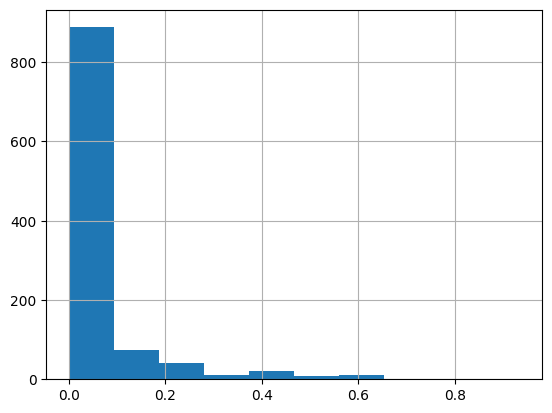

In [35]:
final_df.pfub_erlass_prob.hist()

<Axes: >

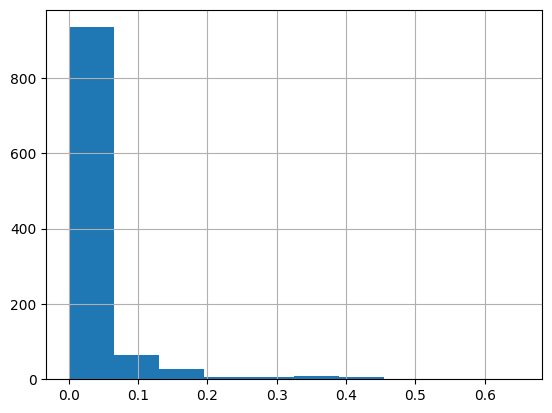

In [36]:
final_df.ladung_va_prob.hist()

In [37]:
final_df

,zendesk_id,attachment_id,attachment_url,s3_object_key,text_with_page_markers,text,text_w_tags,pfub_erlass_prob,pfub_erlass_pred,ladung_va_prob,ladung_va_pred,cleaned_text,cleaned_text_w_page_markers
0,16949451,16949451-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949451-1.pdf,<page_1>\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nK...,\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nKilger & ...,kilger & fülleborn\nrechtsanwalte\nkilger & fü...,0.01,False,0.01,False,kilger & fülleborn\nrechtsanwalte\nkilger & fü...,<page_1>\nkilger & fülleborn\nrechtsanwalte\nk...
1,16949470,16949470-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949470-1.pdf,<page_1>\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEG...,\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\nD...,ev.-luth\nkirchenkreis\nplön-segeberg\ndiakoni...,0.00,False,0.00,False,ev.-luth\nkirchenkreis\nplön-segeberg\ndiakoni...,<page_1>\nev.-luth\nkirchenkreis\nplön-segeber...
2,16949469,16949469-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949469-1.pdf,<page_1>\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SE...,\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\n...,ev.-luth.\nkirchenkreis\nplön-segeberg\ndiakon...,0.00,False,0.00,False,ev.-luth.\nkirchenkreis\nplön-segeberg\ndiakon...,<page_1>\nev.-luth.\nkirchenkreis\nplön-segebe...
3,16949477,16949477-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949477-1.pdf,<page_1>\nhamburger arbeit\nÖffentliche Schuld...,\nhamburger arbeit\nÖffentliche Schuldner- und...,hamburger arbeit\nöffentliche schuldner- und\n...,0.00,False,0.00,False,hamburger arbeit\nöffentliche schuldner- und\n...,<page_1>\nhamburger arbeit\nöffentliche schuld...
4,16949480,16949480-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949480-1.pdf,<page_1>\nverbraucherzentrale\nSchleswig-Holst...,\nverbraucherzentrale\nSchleswig-Holstin\nSchu...,verbraucherzentrale\nschleswig-holstin\nschuld...,0.00,False,0.00,False,verbraucherzentrale\nschleswig-holstin\nschuld...,<page_1>\nverbraucherzentrale\nschleswig-holst...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,16972231,16972231-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16972231-1.pdf,"<page_1>\nAndrea Reinecke\nBrettin, 01.10.2025...","\nAndrea Reinecke\nBrettin, 01.10.2025\nHeinri...","andrea reinecke\nbrettin, <DATE>\nheinrich-hei...",0.01,False,0.06,False,"andrea reinecke\nbrettin, 01.10.2025\nheinrich...","<page_1>\nandrea reinecke\nbrettin, 01.10.2025..."
1051,16918425,16918425-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16918425-1.pdf,<page_1>\nMelda Portakal\nHeiligkreuzgasse 34\...,\nMelda Portakal\nHeiligkreuzgasse 34\nGericht...,melda portakal\nheiligkreuzgasse <NUMBER>\nger...,0.01,False,0.28,False,melda portakal\nheiligkreuzgasse 34\ngerichtsv...,<page_1>\nmelda portakal\nheiligkreuzgasse 34\...
1052,16898832,16898832-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898832-1.pdf,<page_1>\nObergerichtsvollzieherin D. Donner\n...,\nObergerichtsvollzieherin D. Donner\nDienstko...,obergerichtsvollzieherin d. donner\ndienstkont...,0.08,False,0.09,False,obergerichtsvollzieherin d. donner\ndienstkont...,<page_1>\nobergerichtsvollzieherin d. donner\n...
1053,16898843,16898843-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898843-1.pdf,<page_1>\nGerichtsvollzieherin\nSpessartstraße...,\nGerichtsvollzieherin\nSpessartstraße 46\nNic...,gerichtsvollzieherin\nspessartstraße <NUMBER>\...,0.00,False,0.00,False,gerichtsvollzieherin\nspessartstraße 46\nnicol...,<page_1>\ngerichtsvollzieherin\nspessartstraße...


In [38]:
final_df.columns

Index(['zendesk_id', 'attachment_id', 'attachment_url', 's3_object_key',
       'text_with_page_markers', 'text', 'text_w_tags', 'pfub_erlass_prob',
       'pfub_erlass_pred', 'ladung_va_prob', 'ladung_va_pred', 'cleaned_text',
       'cleaned_text_w_page_markers'],
      dtype='object')

In [2]:

import pandas as pd
all_preds = pd.read_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/letters/final_letter_data_all_preds.csv")

In [3]:
all_preds

,zendesk_id,attachment_id,attachment_url,s3_object_key,text_with_page_markers,text,text_w_tags,pfub_erlass_prob,pfub_erlass_pred,ladung_va_prob,ladung_va_pred,cleaned_text,cleaned_text_w_page_markers,is_va,is_dritt
0,16949451,16949451-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949451-1.pdf,<page_1>\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nK...,\nKILGER & FÜLLEBORN\nRECHTSANWALTE\nKilger & ...,kilger & fülleborn\nrechtsanwalte\nkilger & fü...,0.01,False,0.01,False,kilger & fülleborn\nrechtsanwalte\nkilger & fü...,<page_1>\nkilger & fülleborn\nrechtsanwalte\nk...,False,False
1,16949470,16949470-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949470-1.pdf,<page_1>\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEG...,\nEV.-LUTH\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\nD...,ev.-luth\nkirchenkreis\nplön-segeberg\ndiakoni...,0.00,False,0.00,False,ev.-luth\nkirchenkreis\nplön-segeberg\ndiakoni...,<page_1>\nev.-luth\nkirchenkreis\nplön-segeber...,False,False
2,16949469,16949469-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949469-1.pdf,<page_1>\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SE...,\nEV.-LUTH.\nPS\nKIRCHENKREIS\nPLÖN-SEGEBERG\n...,ev.-luth.\nkirchenkreis\nplön-segeberg\ndiakon...,0.00,False,0.00,False,ev.-luth.\nkirchenkreis\nplön-segeberg\ndiakon...,<page_1>\nev.-luth.\nkirchenkreis\nplön-segebe...,False,False
3,16949477,16949477-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949477-1.pdf,<page_1>\nhamburger arbeit\nÖffentliche Schuld...,\nhamburger arbeit\nÖffentliche Schuldner- und...,hamburger arbeit\nöffentliche schuldner- und\n...,0.00,False,0.00,False,hamburger arbeit\nöffentliche schuldner- und\n...,<page_1>\nhamburger arbeit\nöffentliche schuld...,False,False
4,16949480,16949480-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16949480-1.pdf,<page_1>\nverbraucherzentrale\nSchleswig-Holst...,\nverbraucherzentrale\nSchleswig-Holstin\nSchu...,verbraucherzentrale\nschleswig-holstin\nschuld...,0.00,False,0.00,False,verbraucherzentrale\nschleswig-holstin\nschuld...,<page_1>\nverbraucherzentrale\nschleswig-holst...,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,16972231,16972231-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16972231-1.pdf,"<page_1>\nAndrea Reinecke\nBrettin, 01.10.2025...","\nAndrea Reinecke\nBrettin, 01.10.2025\nHeinri...","andrea reinecke\nbrettin, <DATE>\nheinrich-hei...",0.01,False,0.06,False,"andrea reinecke\nbrettin, 01.10.2025\nheinrich...","<page_1>\nandrea reinecke\nbrettin, 01.10.2025...",False,False
1051,16918425,16918425-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16918425-1.pdf,<page_1>\nMelda Portakal\nHeiligkreuzgasse 34\...,\nMelda Portakal\nHeiligkreuzgasse 34\nGericht...,melda portakal\nheiligkreuzgasse <NUMBER>\nger...,0.01,False,0.28,False,melda portakal\nheiligkreuzgasse 34\ngerichtsv...,<page_1>\nmelda portakal\nheiligkreuzgasse 34\...,False,False
1052,16898832,16898832-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898832-1.pdf,<page_1>\nObergerichtsvollzieherin D. Donner\n...,\nObergerichtsvollzieherin D. Donner\nDienstko...,obergerichtsvollzieherin d. donner\ndienstkont...,0.08,False,0.09,False,obergerichtsvollzieherin d. donner\ndienstkont...,<page_1>\nobergerichtsvollzieherin d. donner\n...,False,False
1053,16898843,16898843-1,https://support.pairfinance.de/attachments/tok...,ocr_source_files/letters/16898843-1.pdf,<page_1>\nGerichtsvollzieherin\nSpessartstraße...,\nGerichtsvollzieherin\nSpessartstraße 46\nNic...,gerichtsvollzieherin\nspessartstraße <NUMBER>\...,0.00,False,0.00,False,gerichtsvollzieherin\nspessartstraße 46\nnicol...,<page_1>\ngerichtsvollzieherin\nspessartstraße...,True,False


In [4]:
all_preds.is_va.value_counts()

is_va
False    1027
True       24
Name: count, dtype: int64

In [5]:
all_preds.is_dritt.value_counts()

is_dritt
False    927
True     124
Name: count, dtype: int64